In [2]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from lowRank.NMLRSSE_Strang import NMLRSSE_Strang
from lowRank import compute_expectation as ce
from utils.noise_generator import ColoredNoiseGenerator_Cholesky
from utils import multi_index

# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    t_arr = np.asarray(t)
    t1 = np.atleast_1d(t_arr).astype(float)
    phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    return out[0] if t_arr.ndim == 0 else out

# spin-boson model parameters
eps = [0, Delta, 2*Delta]
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = [Delta*sx + e*sz for e in eps]
L = sz

MultiIndex layers: 100%|██████████| 9/9 [00:00<00:00, 39.60it/s]


Low-rank decomposition done in 0.11 seconds.


Trajectories: 100%|██████████| 10000/10000 [42:30<00:00,  3.92it/s] 


Relative error for eps=0: 2.139e-02


MultiIndex layers: 100%|██████████| 9/9 [00:00<00:00, 123.39it/s]


...

Relative error for eps=1: 4.093e-02


MultiIndex layers: 100%|██████████| 9/9 [00:00<00:00, 94.90it/s]


Low-rank decomposition done in 0.20 seconds.


Trajectories: 100%|██████████| 10000/10000 [41:33<00:00,  4.01it/s] 


Relative error for eps=2: 3.487e-02


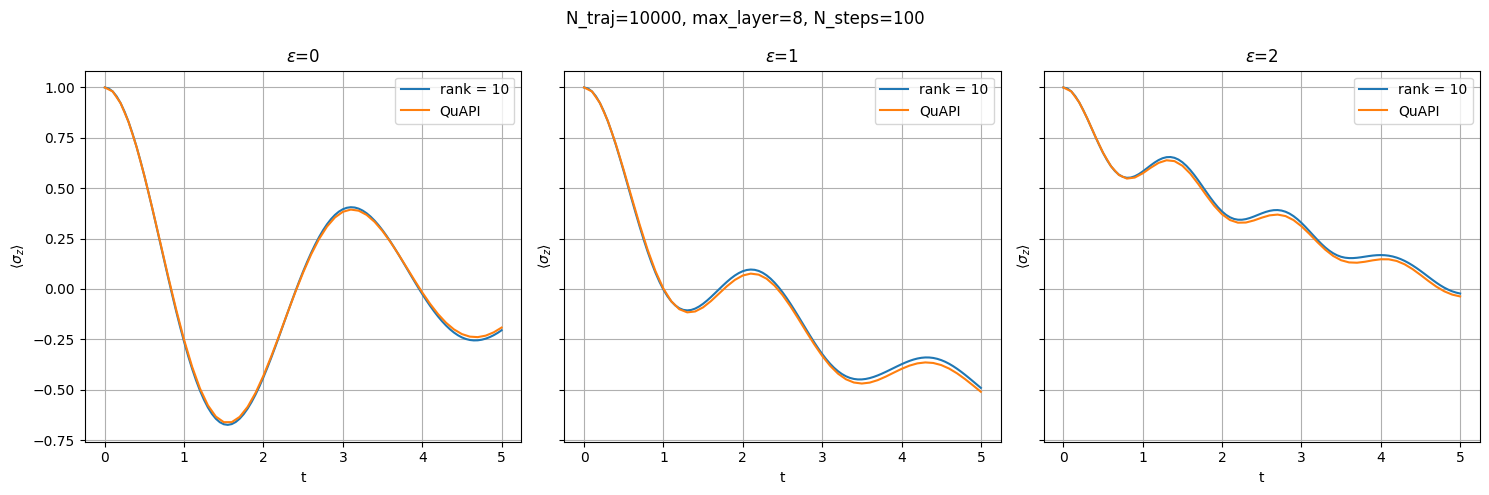

In [ ]:
# parameters for the simulation
tmax = 5.0 / Delta
N_steps = 100
psi0 = np.array([1.0, 0.0], dtype=complex)
N_traj = 10000
rank = 10
# hierarchy truncation (total order cutoff for the multi-index set)
# set smaller than N_steps to avoid combinatorial blow-up when rank grows
max_layer = 8
parallel_traj = True

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for idx in range(3):
    NMLRSSE_solver = NMLRSSE_Strang(
        Hs = Hs[idx],
        L = L,
        bath_corr = bath_corr,
        tmax = tmax,
        N_steps = N_steps,
        rank = rank,
        max_layer = max_layer,
    )
    psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
    sigma_z = ce.compute_expectation_value_linear(psis, sz)
    axes[idx].plot(NMLRSSE_solver.t_grid, sigma_z, label='rank = {}'.format(rank))
    data = np.load("ref_spinboson/eps_{}.npz".format(eps[idx]))
    tgrid = data['t']
    sigmaz = data['sz']
    axes[idx].plot(tgrid, sigmaz, label='QuAPI')
    axes[idx].set_xlabel('t')
    axes[idx].set_ylabel(r'$\langle \sigma_z \rangle$')
    axes[idx].set_title(r'$\epsilon$={}'.format(eps[idx]))
    axes[idx].grid()
    axes[idx].legend()
    test_op = sigma_z[::(N_steps//50)]
    error = np.linalg.norm(test_op - sigmaz) / np.linalg.norm(sigmaz)
    print("Relative error for eps={}: {:.3e}".format(eps[idx], error))

plt.suptitle('N_traj={}, max_layer={}, N_steps={}'.format(N_traj, max_layer, N_steps))
plt.tight_layout()
plt.show()

### Convergence test

MultiIndex layers: 100%|██████████| 7/7 [00:00<00:00, 1099.75it/s]


Low-rank decomposition done in 26.52 seconds.


MultiIndex layers: 100%|██████████| 7/7 [00:00<00:00, 2350.50it/s]


Low-rank decomposition done in 0.02 seconds.


MultiIndex layers: 100%|██████████| 7/7 [00:00<00:00, 903.92it/s]


...

MultiIndex layers: 100%|██████████| 7/7 [00:00<00:00, 985.37it/s]


Low-rank decomposition done in 0.62 seconds.


MultiIndex layers: 100%|██████████| 7/7 [00:00<00:00, 851.66it/s]


Low-rank decomposition done in 1.61 seconds.


Trajectories: 100%|██████████| 100/100 [00:04<00:00, 22.15it/s]


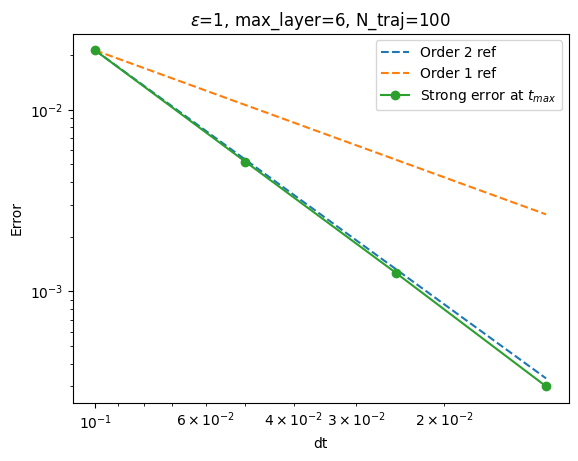

In [ ]:
example = 1
# parameters for the simulation
base = 50
tmax = 5.0 / Delta
N_steps = np.array([1, 2, 4, 8]) * base
ref_N_steps = 1600
psi0 = np.array([1.0, 0.0], dtype=complex)
N_traj = 100
rank = 8
max_layer = 6
parallel_traj = True

# generate fixed noise trajectories
Z = np.empty((N_traj, ref_N_steps+1), dtype=np.complex128)
noise_gen = ColoredNoiseGenerator_Cholesky(bath_corr, tmax, ref_N_steps)
for traj in range(N_traj):
    z = np.asarray(noise_gen.sample_process(), dtype=np.complex128)
    Z[traj, :] = z[:]

# generate fixed SVD for the bath correlation matrix
# tgrid_ref = np.linspace(0, tmax, ref_N_steps+1)
# C_ref = np.empty((ref_N_steps+1, ref_N_steps+1), dtype=complex)
# for i in range(ref_N_steps+1):
#     for j in range(ref_N_steps+1):
#         C_ref[i, j] = bath_corr(tgrid_ref[i] - tgrid_ref[j])
# U, S, V = np.linalg.svd(C_ref)
# Ur = U[:, :rank]
# Sr = S[:rank]
# Vr = V[:rank, :]

NMLRSSE_solver = NMLRSSE_Strang(
    Hs = Hs[example],
    L = L,
    bath_corr = bath_corr,
    tmax = tmax,
    N_steps = ref_N_steps,
    rank = rank,
    max_layer = max_layer,
    do_low_rank_decomposition=True,
    noise_sample_Z = Z,
)
# NMLRSSE_solver.set_SVD(Sr, Ur, Vr)
ref_psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
ref_psi_end = ref_psis[:, -1, :]
ref_psi_end_ex = np.sum(ref_psi_end, axis=0) / N_traj


strong_error_end = []
weak_error_end = []
for steps in N_steps:
    NMLRSSE_solver = NMLRSSE_Strang(
        Hs = Hs[example],
        L = L,
        bath_corr = bath_corr,
        tmax = tmax,
        N_steps = steps,
        rank = rank,
        max_layer = max_layer,
        do_low_rank_decomposition=True,
        noise_sample_Z = Z[:, ::(ref_N_steps // steps)],
    )
    # ds = ref_N_steps // steps
    # NMLRSSE_solver.set_SVD(Sr, Ur[::ds, :], Vr[:, ::ds])
    psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
    psi_end = psis[:, -1, :]
    weak_err_end = np.linalg.norm(np.sum(psi_end, axis=0) / N_traj - ref_psi_end_ex)
    weak_error_end.append(weak_err_end)
    strong_err_end = np.mean(np.linalg.norm(psi_end - ref_psi_end, axis=1))
    strong_error_end.append(strong_err_end)

h = tmax/np.array(N_steps)
c_ref = strong_error_end[0] / (h[0])**2
ref_line = c_ref * (h**2)
plt.loglog(h, ref_line, '--', label='Order 2 ref')
c_ref = strong_error_end[0] / (h[0])
ref_line = c_ref * (h)
plt.loglog(h, ref_line, '--', label='Order 1 ref')
# plt.loglog(h, weak_error_end, marker='s', label=r'Weak error at $t_{max}$')
plt.loglog(h, strong_error_end, marker='o', label=r'Strong error at $t_{max}$')
plt.xlabel('dt')
plt.ylabel('Error')
plt.gca().invert_xaxis()
plt.title(r'$\epsilon$={}, max_layer={}, N_traj={}'.format(eps[example], max_layer, N_traj))
plt.legend()
plt.show()